In [23]:
import pandas as pd
import os
import sys
from omegaconf import OmegaConf
import matplotlib.pyplot as plt
import json
import joblib
import ast

# Adjust the path to point to external/AlphaPEM
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.sampling.sampler import get_polarisation_curve_samples, build_fixed_parameters
from src.validity.validity_criteria import validate_polarization_curves

In [24]:
data = pd.read_pickle(r"../sampling_test/validated_final_df_57344_imputed.pkl")
data = data[data['classification'] == 'valid']
parameter_ranges = OmegaConf.load('../param_config.yaml')

In [25]:
data["classification"].value_counts()

classification
valid    56312
Name: count, dtype: int64

In [26]:
criteria = {
    "start_in_range": True,
    "approx_monotonic": True,
    "low_ifc_positive_voltage": True
}

validated_df = validate_polarization_curves(
    data,
    apply_criteria=criteria,
    filter_invalid=True,
    voltage_range=(0, 1.23),
    approx_monotonic_threshold=0.05
)

print(len(validated_df))

54754


In [6]:
columns = list(parameter_ranges.keys())
columns.extend(['Ucell', 'ifc', 'SHA256'])

n_configs = 10000
sampled_df = validated_df.sample(n=n_configs, random_state=42).reset_index(drop=True)

# Explode both columns together
df_exploded = sampled_df[columns].explode(['ifc', 'Ucell'], ignore_index=True)

print("\nExploded DataFrame:")
print(len(df_exploded))
df_exploded.head()


Exploded DataFrame:
310000


,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,Re,i0_c_ref,kappa_co,kappa_c,Ucell,ifc,SHA256
0,343.804109,214920.650007,2.431343,0.48481,0.731942,3.325909,0.289988,0.198927,5,0.000003,40.551519,33.053013,0.177528,0.971062,0.000813,f1bb7220e0a9e4d7ec051d321cbc53c20910f205e6f7fb...
1,343.804109,214920.650007,2.431343,0.48481,0.731942,3.325909,0.289988,0.198927,5,0.000003,40.551519,33.053013,0.177528,0.927253,0.100812,f1bb7220e0a9e4d7ec051d321cbc53c20910f205e6f7fb...
2,343.804109,214920.650007,2.431343,0.48481,0.731942,3.325909,0.289988,0.198927,5,0.000003,40.551519,33.053013,0.177528,0.8958,0.200812,f1bb7220e0a9e4d7ec051d321cbc53c20910f205e6f7fb...
3,343.804109,214920.650007,2.431343,0.48481,0.731942,3.325909,0.289988,0.198927,5,0.000003,40.551519,33.053013,0.177528,0.87028,0.300812,f1bb7220e0a9e4d7ec051d321cbc53c20910f205e6f7fb...
4,343.804109,214920.650007,2.431343,0.48481,0.731942,3.325909,0.289988,0.198927,5,0.000003,40.551519,33.053013,0.177528,0.848665,0.400812,f1bb7220e0a9e4d7ec051d321cbc53c20910f205e6f7fb...


In [7]:
X = df_exploded[list(parameter_ranges.keys()) + ['ifc']]
y = df_exploded['Ucell']

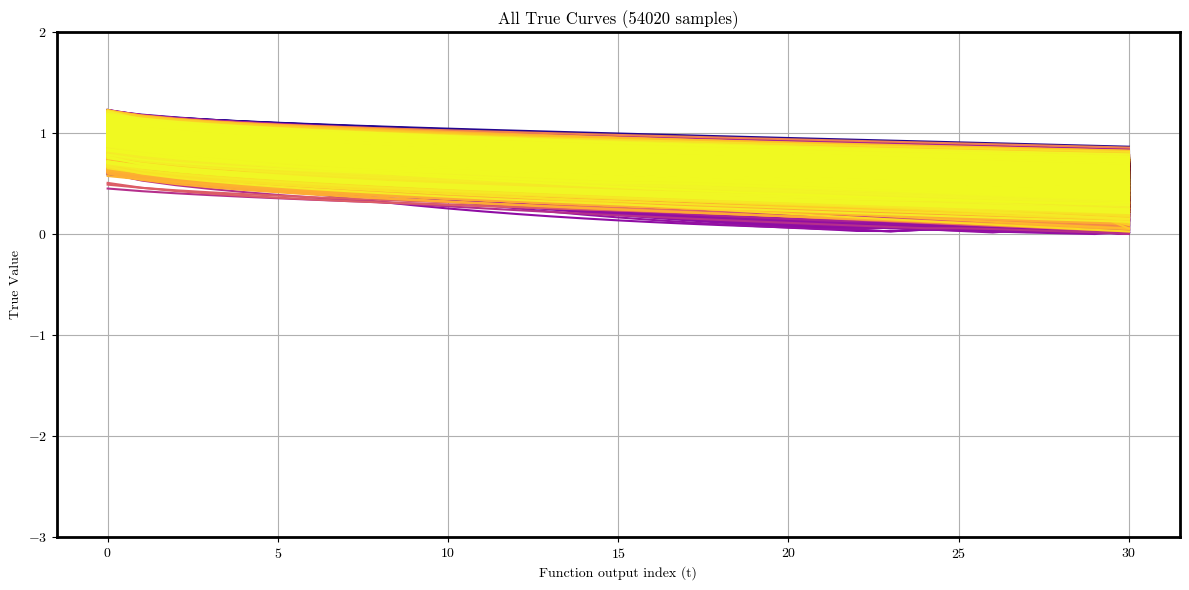

In [27]:
import matplotlib.pyplot as plt
import numpy as np

def plot_all_true_curves(Y_true):
    """
    Plot all true curves from Y_true.
    
    Args:
        Y_true (np.array): True function outputs, shape (n_samples_total, T)
    """
    n_samples = Y_true.shape[0]
    
    plt.figure(figsize=(12, 6))
    colors = plt.cm.plasma(np.linspace(0, 1, n_samples))
    
    for idx, color in zip(range(n_samples), colors):
        t = np.arange(Y_true.shape[1])
        plt.plot(t, Y_true[idx], label=f'Sample {idx}', color=color)
    
    plt.xlabel('Function output index (t)')
    plt.ylabel('True Value')
    plt.title(f'All True Curves ({n_samples} samples)')
    plt.grid(True)
    plt.ylim(-3, 2)
    # Uncomment if you want legend:
    # plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

all_Y = np.array(data['Ucell'].tolist())

mask_negative = np.any(all_Y < 0, axis=1)

# Get those curves
curves_with_negative = all_Y[mask_negative]
positive_curves = all_Y[~mask_negative]
plot_all_true_curves(positive_curves)


In [8]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, RationalQuadratic, ConstantKernel as C
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

def nested_cv_train_with_groups(X, y, groups, model_name='rf', outer_splits=5, inner_splits=3, random_state=42):
    """
    Nested CV with GroupKFold (groups provided) and grid search for GP, XGBoost, or RF.
    """

    print(f"\n[INFO] Starting nested CV for model: {model_name}")
    print(f"[INFO] Total samples: {len(X)}, grouped into {len(np.unique(groups))} unique groups")
    print(f"[INFO] Outer CV folds: {outer_splits}, Inner CV folds: {inner_splits}\n")

    outer_cv = GroupKFold(n_splits=outer_splits)
    inner_cv = GroupKFold(n_splits=inner_splits)

    # Choose model and grid
    if model_name == 'rf':
        estimator = RandomForestRegressor(random_state=random_state)
        param_grid = {
            'n_estimators': [100, 200, 500],
            'max_depth': [None, 5, 10],
            'min_samples_split': [2, 5, 10]
        }
    elif model_name == 'xgboost':
        estimator = XGBRegressor(random_state=random_state, verbosity=0)
        param_grid = {
            "n_estimators": [300, 500, 700],
            "max_depth": [6, 8, 10],
            "learning_rate": [0.01, 0.05],
            "subsample": [0.8, 1.0],
            "colsample_bytree": [0.8, 1.0]
        }
    elif model_name == 'gp':
        kernel = C(1.0) * RBF(length_scale=1.0)
        estimator = GaussianProcessRegressor(kernel=kernel, normalize_y=True, random_state=random_state)
        param_grid = {
            'kernel': [
                C(1.0, (0.1, 10.0)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)),
                C(1.0, (0.1, 10.0)) * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=1.5),
                C(1.0, (0.1, 10.0)) * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5),
                C(1.0, (0.1, 10.0)) * RationalQuadratic(length_scale=1.0, alpha=0.1)
            ],
            'alpha': [1e-10, 1e-5, 1e-2]
        }
    else:
        raise ValueError(f"[ERROR] Unknown model name: {model_name}")

    # Count total param combinations
    from itertools import product
    total_combinations = len(list(product(*param_grid.values())))
    print(f"[INFO] Defined hyperparameter grid with {total_combinations} combinations\n")

    r2_scores = []
    mse_scores = []
    mae_scores = []
    best_params_list = []

    for outer_fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y, groups=groups), 1):
        print(f"[INFO] → Starting outer fold {outer_fold}/{outer_splits}")
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        groups_train = groups[train_idx]

        print(f"[INFO]    Train size: {X_train.shape}, Test size: {X_test.shape}")
        print(f"[INFO]    Performing inner grid search ({inner_splits}-fold CV)...")

        grid_search = GridSearchCV(
            estimator,
            param_grid,
            cv=inner_cv.split(X_train, y_train, groups=groups_train),
            scoring='r2',
            n_jobs=-1,
            verbose=0
        )
        grid_search.fit(X_train, y_train)

        best_model = grid_search.best_estimator_
        best_params = grid_search.best_params_
        print(f"[INFO]    Best hyperparameters for fold {outer_fold}: {best_params}")

        y_pred = best_model.predict(X_test)

        r2 = r2_score(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)

        r2_scores.append(r2)
        mse_scores.append(mse)
        mae_scores.append(mae)
        best_params_list.append(best_params)

        print(f"[INFO]    Fold {outer_fold} performance — R²: {r2:.4f}, RMSE: {np.sqrt(mse):.4f}, MAE: {mae:.4f}\n")

    print("[INFO] Finished all folds.")
    print("[INFO] → Summary:")
    print(f"   R2 mean ± std:  {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")
    print(f"   RMSE mean ± std: {np.sqrt(np.mean(mse_scores)):.4f} ± {np.std(np.sqrt(mse_scores)):.4f}")
    print(f"   MAE mean ± std:  {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}\n")

    metrics = {
        'R2_mean': np.mean(r2_scores),
        'R2_std': np.std(r2_scores),
        'R2_all': r2_scores,
        'MSE_mean': np.mean(mse_scores),
        'MSE_std': np.std(mse_scores),
        'MSE_all': mse_scores,
        'MAE_mean': np.mean(mae_scores),
        'MAE_std': np.std(mae_scores),
        'MAE_all': mae_scores
    }

    return metrics, best_params_list

In [9]:
def save_nested_cv_results(X, y, groups, model_name, nested_cv_fn, 
                            save_dir='results', run_name='model_run',
                            outer_splits=5, inner_splits=3, random_state=42):
    """
    Runs nested CV using a given function, saves metrics, best params, and retrains final model.
    
    Parameters:
    - X, y, groups: Input features, targets, and grouping info
    - model_name: 'rf', 'xgboost', 'gp', etc. (must be supported by nested_cv_fn)
    - nested_cv_fn: function(X, y, groups, model_name, outer_splits, inner_splits, random_state)
                    must return (metrics_dict, best_params_list)
    - save_dir: folder to store results
    - run_name: identifier for files
    - outer_splits, inner_splits: CV configuration
    - random_state: reproducibility

    Returns:
    - final_model: trained on all data with best hyperparameters
    - metrics: dict of evaluation scores
    - best_params_list: list of best param dicts per outer fold
    """

    os.makedirs(save_dir, exist_ok=True)

    # Run nested CV
    metrics, best_params_list = nested_cv_fn(
        X.to_numpy(), y.to_numpy(), groups.to_numpy(),
        model_name=model_name,
        outer_splits=outer_splits,
        inner_splits=inner_splits,
        random_state=random_state
    )

    # Save metrics & best params
    metrics_path = os.path.join(save_dir, f"{run_name}_metrics.json")
    params_path = os.path.join(save_dir, f"{run_name}_best_params.json")
    with open(metrics_path, 'w') as f:
        json.dump(metrics, f, indent=4)
    with open(params_path, 'w') as f:
        json.dump(best_params_list, f, indent=4)

    print(f"Saved metrics to {metrics_path}")
    print(f"Saved best params to {params_path}")

    best_params_final = best_params_list[0]  # Could be improved with voting

    if model_name == 'rf':
        model = RandomForestRegressor(random_state=random_state, **best_params_final)
    elif model_name == 'xgboost':
        model = XGBRegressor(random_state=random_state, **best_params_final)
    elif model_name == 'gp':
        model = GaussianProcessRegressor(normalize_y=True, random_state=random_state, **best_params_final)
    else:
        raise ValueError(f"Unsupported model type: {model_name}")

    model.fit(X, y)
    model_path = os.path.join(save_dir, f"{run_name}_final_model.pkl")
    joblib.dump(model, model_path)
    print(f"Saved final model to {model_path}")

    return model, metrics, best_params_list

In [ ]:
final_model_rf, metrics_rf, best_params_rf = save_nested_cv_results(
    X, y, df_exploded['SHA256'],
    model_name='rf',  # or 'xgboost' or 'gp'
    nested_cv_fn=nested_cv_train_with_groups,
    save_dir='../results/sm/randomForest',
    run_name='randomForest',
)


[INFO] Starting nested CV for model: rf
[INFO] Total samples: 310000, grouped into 9958 unique groups
[INFO] Outer CV folds: 5, Inner CV folds: 3

[INFO] Defined hyperparameter grid with 27 combinations

[INFO] → Starting outer fold 1/5
[INFO]    Train size: (248000, 14), Test size: (62000, 14)
[INFO]    Performing inner grid search (3-fold CV)...


In [ ]:
final_model_xgb, metrics_xgb, best_params_xgb = save_nested_cv_results(
    X, y, df_exploded['SHA256'],
    model_name='xgboost',  # or 'xgboost' or 'gp'
    nested_cv_fn=nested_cv_train_with_groups,
    save_dir='../results/sm/xgboost',
    run_name='xgboost',
)


[INFO] Starting nested CV for model: xgboost
[INFO] Total samples: 310000, grouped into 9958 unique groups
[INFO] Outer CV folds: 5, Inner CV folds: 3

[INFO] Defined hyperparameter grid with 72 combinations

[INFO] → Starting outer fold 1/5
[INFO]    Train size: (248000, 14), Test size: (62000, 14)
[INFO]    Performing inner grid search (3-fold CV)...


In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, RationalQuadratic, ConstantKernel as C
from sklearn.model_selection import GroupShuffleSplit, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

def train_val_test_random_search(X, y, groups, model_name='rf', 
                                 test_size=0.2, val_size=0.2, 
                                 n_iter=20, random_state=42):
    """
    One train-validation-test split with GroupShuffleSplit.
    Randomized search for hyperparameter tuning on train+val split.
    Test set used only once for final evaluation.
    
    Parameters:
        X, y, groups: data and group labels.
        model_name: 'rf', 'xgboost' or 'gp'.
        test_size: fraction of data used for test set.
        val_size: fraction of train+val used for validation.
        n_iter: number of random search iterations.
        random_state: random seed.
    """

    print(f"[INFO] Starting train-validation-test split with random search for model: {model_name}")
    print(f"[INFO] Total samples: {len(X)}, unique groups: {len(np.unique(groups))}")
    print(f"[INFO] Test size: {test_size}, Validation size: {val_size} (of train+val)")
    print(f"[INFO] Number of random search iterations: {n_iter}\n")

    # Split into train+val and test with group shuffle split
    gss_test = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    trainval_idx, test_idx = next(gss_test.split(X, y, groups))

    X_trainval, X_test = X[trainval_idx], X[test_idx]
    y_trainval, y_test = y[trainval_idx], y[test_idx]
    groups_trainval = groups[trainval_idx]

    # Split trainval into train and validation
    gss_val = GroupShuffleSplit(n_splits=1, test_size=val_size, random_state=random_state)
    train_idx, val_idx = next(gss_val.split(X_trainval, y_trainval, groups_trainval))

    X_train, X_val = X_trainval[train_idx], X_trainval[val_idx]
    y_train, y_val = y_trainval[train_idx], y_trainval[val_idx]

    print(f"[INFO] Sizes — Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}\n")

    # Define model and param distributions for random search
    if model_name == 'rf':
        estimator = RandomForestRegressor(random_state=random_state)
        param_dist = {
            'n_estimators': [50, 100, 200],
            'max_depth': [None, 5, 10],
            'min_samples_split': [2, 5, 10]
        }
    elif model_name == 'xgboost':
        estimator = XGBRegressor(random_state=random_state, verbosity=0)
        param_dist = {
            "n_estimators": [300, 500, 700],
            "max_depth": [6, 8, 10],
            "learning_rate": [0.01, 0.05],
            "subsample": [0.8, 1.0],
            "colsample_bytree": [0.8, 1.0]
        }
    elif model_name == 'gp':
        kernel = C(1.0) * RBF(length_scale=1.0)
        estimator = GaussianProcessRegressor(kernel=kernel, normalize_y=True, random_state=random_state)
        param_dist = {
            'kernel': [
                C(1.0, (0.1, 10.0)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)),
                C(1.0, (0.1, 10.0)) * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=1.5),
                C(1.0, (0.1, 10.0)) * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5),
                C(1.0, (0.1, 10.0)) * RationalQuadratic(length_scale=1.0, alpha=0.1)
            ],
            'alpha': [1e-10, 1e-5, 1e-2]
        }
    else:
        raise ValueError(f"[ERROR] Unknown model name: {model_name}")

    # RandomizedSearchCV on train set only, validate on val set manually
    random_search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring='r2',
        n_jobs=-1,
        cv=[(np.arange(len(X_train)), np.arange(len(X_train), len(X_train)))],  # dummy cv to fit on train only
        refit=False,
        random_state=random_state,
        verbose=0
    )

    # Fit randomized search on train data only
    random_search.fit(X_train, y_train)

    # Manually pick best hyperparameters based on validation set
    best_score = -np.inf
    best_params = None
    for params in random_search.cv_results_['params']:
        model = estimator.set_params(**params)
        model.fit(X_train, y_train)
        val_pred = model.predict(X_val)
        val_r2 = r2_score(y_val, val_pred)
        if val_r2 > best_score:
            best_score = val_r2
            best_params = params

    print(f"[INFO] Best hyperparameters from validation: {best_params}")
    print(f"[INFO] Best validation R²: {best_score:.4f}\n")

    # Train best model on train+validation set
    best_model = estimator.set_params(**best_params)
    best_model.fit(X_trainval, y_trainval)

    # Evaluate on test set
    y_pred = best_model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    print(f"[INFO] Test set performance — R²: {r2:.4f}, RMSE: {np.sqrt(mse):.4f}, MAE: {mae:.4f}\n")

    metrics = {
        'R2_test': r2,
        'MSE_test': mse,
        'MAE_test': mae,
        'best_params': best_params
    }

    return metrics


In [16]:
train_val_test_random_search(X[:5000].to_numpy(), y[:5000].to_numpy(), groups=df_exploded['SHA256'][:5000], model_name='gp', 
                                 test_size=0.2, val_size=0.2, 
                                 n_iter=5, random_state=42)

[INFO] Starting train-validation-test split with random search for model: gp
[INFO] Total samples: 5000, unique groups: 162
[INFO] Test size: 0.2, Validation size: 0.2 (of train+val)
[INFO] Number of random search iterations: 5

[INFO] Sizes — Train: (3171, 14), Validation: (806, 14), Test: (1023, 14)



c:\Users\dejvi\Desktop\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan]
  warnings.warn(
c:\Users\dejvi\Desktop\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\dejvi\Desktop\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\

[INFO] Best hyperparameters from validation: {'kernel': 1**2 * RBF(length_scale=1), 'alpha': 1e-10}
[INFO] Best validation R²: -0.0153

[INFO] Test set performance — R²: 0.0004, RMSE: 0.1824, MAE: 0.1385



{'R2_test': 0.00039883478108015957,
 'MSE_test': 0.03328621978244687,
 'MAE_test': 0.13850848520331221,
 'best_params': {'kernel': 1**2 * RBF(length_scale=1), 'alpha': 1e-10}}

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.multioutput import MultiOutputRegressor
from sklearn.gaussian_process.kernels import RBF, DotProduct, WhiteKernel, ConstantKernel
from sklearn.multioutput import RegressorChain

# X: input parameters (n_samples × n_features)
# Y: output functions (n_samples × t_points)
X = np.array(data[parameter_ranges][~mask_negative])
Y = np.array(data['Ucell'][~mask_negative].tolist())

# Filter invalid outputs
#mask_valid = np.all((Y > 0) & (Y < 1.5), axis=1)

def train_GP(X, Y, test_size=0.2, random_state=42):
    # Split data
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=test_size, random_state=random_state)

    # Scale input features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Optional: apply PCA on inputs (not outputs)
    pca = PCA(n_components=0.95)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)


    # Fit multi-output GP
    kernel = RBF(length_scale=1.0) + WhiteKernel(noise_level=1e-3)
    gp = GaussianProcessRegressor(n_restarts_optimizer=10, kernel=kernel, normalize_y=True)
    multi_gp = MultiOutputRegressor(gp)
    multi_gp.fit(X_train_pca, Y_train)

    # Predict means and std deviations
    Y_pred = []
    Y_std = []

    for estimator in multi_gp.estimators_:
        mu, std = estimator.predict(X_test_pca, return_std=True)
        Y_pred.append(mu)
        Y_std.append(std)

    # Convert to (n_samples, n_outputs)
    Y_pred = np.array(Y_pred).T
    Y_std = np.array(Y_std).T

    # Evaluation
    mse_per_point = np.mean((Y_pred - Y_test) ** 2, axis=0)
    avg_mse = np.mean(mse_per_point)
    print("Average MSE across all time points:", avg_mse)

    return multi_gp, Y_test, Y_pred, Y_std, X_test_pca

multi_gp, Y_test, Y_pred, Y_std, X_test_pca = train_GP(X, Y, test_size=0.99, random_state=42)

c:\Users\dejvi\Desktop\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Average MSE across all time points: 0.002775874976062711


In [30]:
from sklearn.metrics import r2_score

# Y_test and Y_pred are assumed to be NumPy arrays or pandas Series
r2 = r2_score(Y_test, Y_pred)
print(f"R² score: {r2:.4f}")


R² score: 0.7538


In [32]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel
from sklearn.multioutput import MultiOutputRegressor
from scipy.stats import uniform

def train_GP_with_HPO(X, Y, test_size=0.2, random_state=42, n_iter=10):
    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=test_size, random_state=random_state)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    pca = PCA(n_components=0.95)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    base_kernel = ConstantKernel(1.0, (1e-2, 10.0)) * \
                  RBF(length_scale=1.0, length_scale_bounds=(1e-2, 10.0)) + \
                  WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-5, 1.0))

    gp = GaussianProcessRegressor(
        kernel=base_kernel,
        normalize_y=True,
        n_restarts_optimizer=5,
        random_state=random_state)

    multi_gp = MultiOutputRegressor(gp)

    param_dist = {
        # Signal variance (ConstantKernel constant_value)
        'estimator__kernel__k1__k1__constant_value': uniform(0.1, 10.0),
        # RBF length-scale
        'estimator__kernel__k1__k2__length_scale': uniform(0.1, 10.0),
        # Noise (WhiteKernel noise_level)
        'estimator__kernel__k2__noise_level': uniform(1e-5, 1e-1),
    }

    search = RandomizedSearchCV(
        multi_gp,
        param_distributions=param_dist,
        n_iter=n_iter,
        cv=3,
        scoring='neg_mean_squared_error',
        verbose=2,
        n_jobs=-1,
        refit=True,
        random_state=random_state
    )

    search.fit(X_train_pca, Y_train)

    best_model = search.best_estimator_

    Y_pred = []
    Y_std = []
    for est in best_model.estimators_:
        mu, std = est.predict(X_test_pca, return_std=True)
        Y_pred.append(mu)
        Y_std.append(std)
    Y_pred = np.array(Y_pred).T
    Y_std = np.array(Y_std).T

    mse_points = np.mean((Y_pred - Y_test)**2, axis=0)
    avg_mse = np.mean(mse_points)
    print("Best params:", search.best_params_)
    print("Average test MSE:", avg_mse)

    return best_model, Y_test, Y_pred, Y_std, X_test_pca

best_model, Y_test, Y_pred, Y_std, X_test_pca = train_GP_with_HPO(X, Y, test_size=0.99, random_state=42, n_iter=10)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params: {'estimator__kernel__k1__k1__constant_value': np.float64(1.9340450985343383), 'estimator__kernel__k1__k2__length_scale': np.float64(3.1424224295953773), 'estimator__kernel__k2__noise_level': np.float64(0.05248564316322379)}
Average test MSE: 0.0026667412332558637


In [33]:
r2 = r2_score(Y_test, Y_pred)
print(f"R² score: {r2:.4f}")


R² score: 0.7647


100%|██████████| 100/100 [04:52<00:00,  2.93s/it]


SHAP summary for output dimension 0


100%|██████████| 100/100 [05:27<00:00,  3.28s/it]


SHAP summary for output dimension 1


100%|██████████| 100/100 [05:34<00:00,  3.35s/it]


...

100%|██████████| 100/100 [06:51<00:00,  4.11s/it]


SHAP summary for output dimension 29


100%|██████████| 100/100 [05:44<00:00,  3.45s/it]

SHAP summary for output dimension 30


MultiOutputRegressor(estimator=GaussianProcessRegressor(kernel=1.39**2 * RBF(length_scale=3.14) + WhiteKernel(noise_level=0.0525),
                                                        n_restarts_optimizer=5,
                                                        normalize_y=True,
                                                        random_state=42))

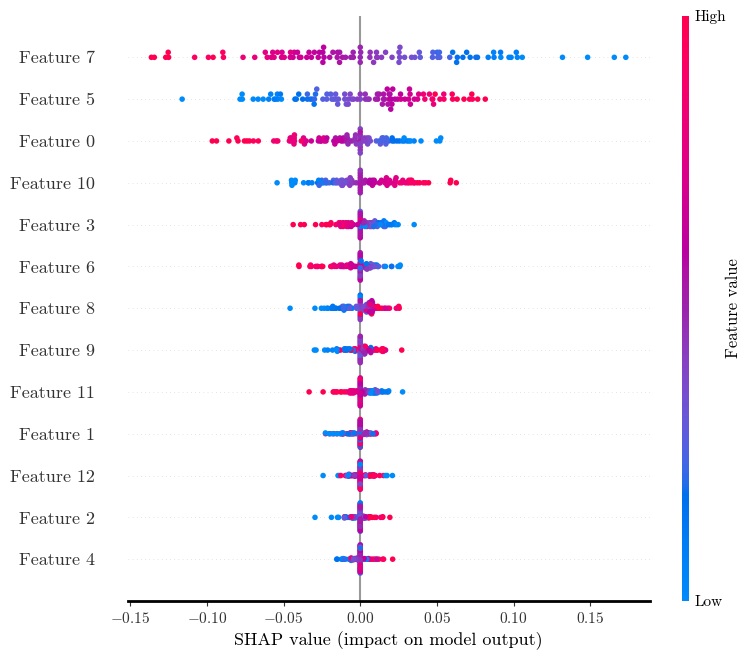

In [37]:
import shap
import numpy as np

# Assume:
# search: the fitted RandomizedSearchCV object
# X_test_pca: the PCA-transformed test data


# SHAP KernelExplainer requires a prediction function
# Loop over each output dimension (each GP estimator)
shap_values_list = []
for i, estimator in enumerate(best_model.estimators_):
    # Use a small background set for efficiency
    background = X_test_pca[np.random.choice(X_test_pca.shape[0], size=100, replace=False)]
    
    # Create SHAP KernelExplainer
    explainer = shap.KernelExplainer(estimator.predict, background)
    
    # Explain a subset of test points (e.g., 100 points)
    shap_values = explainer.shap_values(X_test_pca[:100])
    
    shap_values_list.append(shap_values)

    # Optional: visualize for this output
    print(f"SHAP summary for output dimension {i}")
    shap.summary_plot(shap_values, X_test_pca[:100], show=False)
best_model

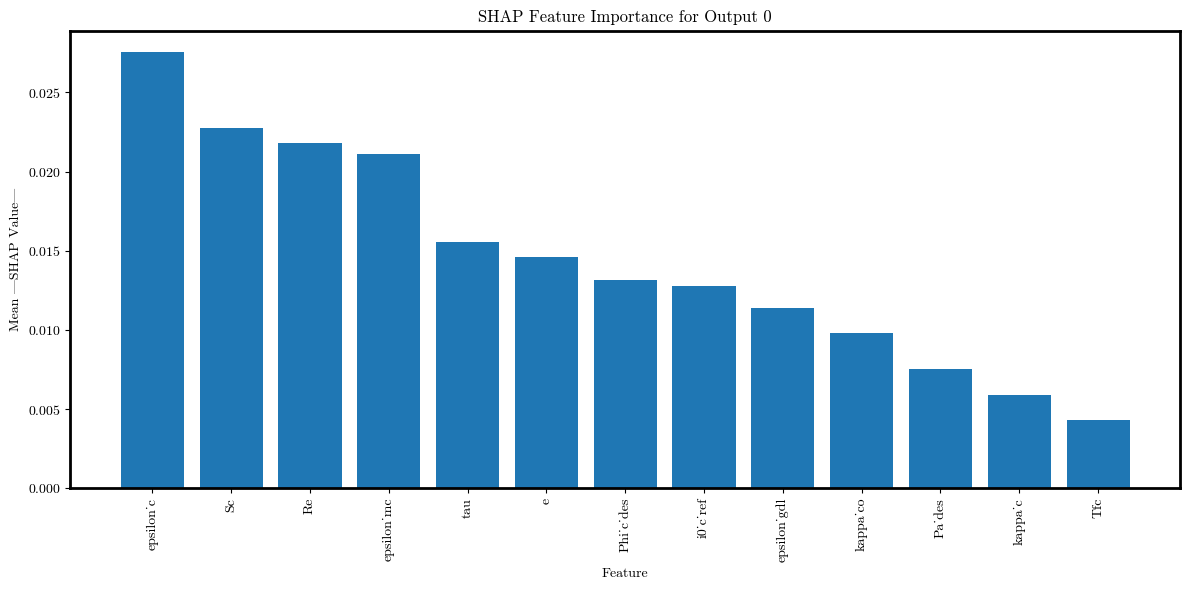

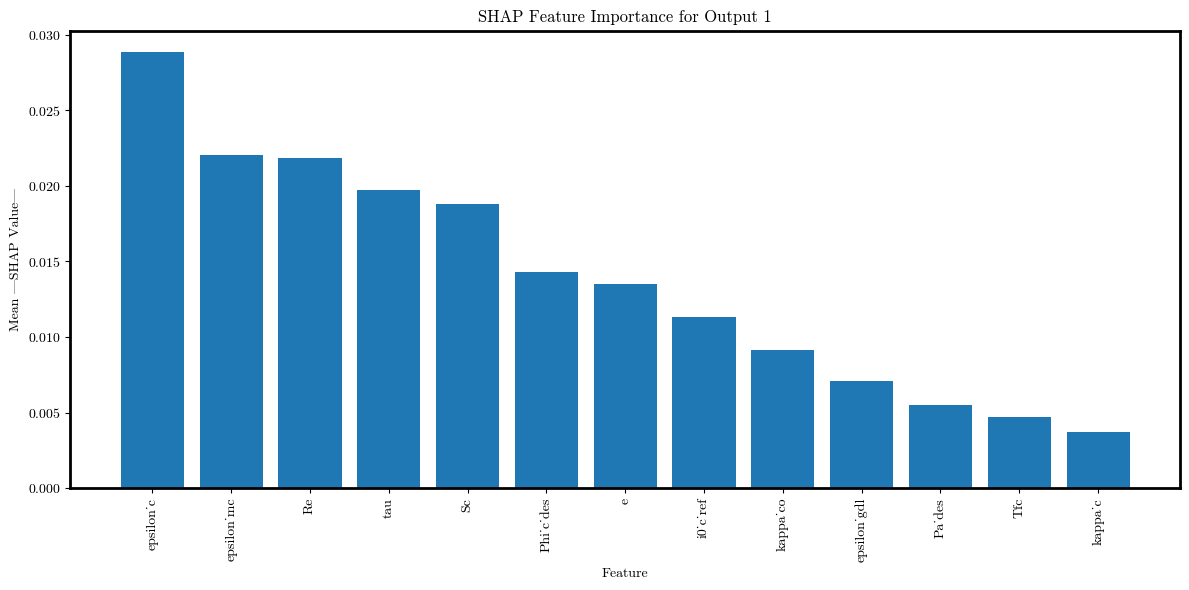

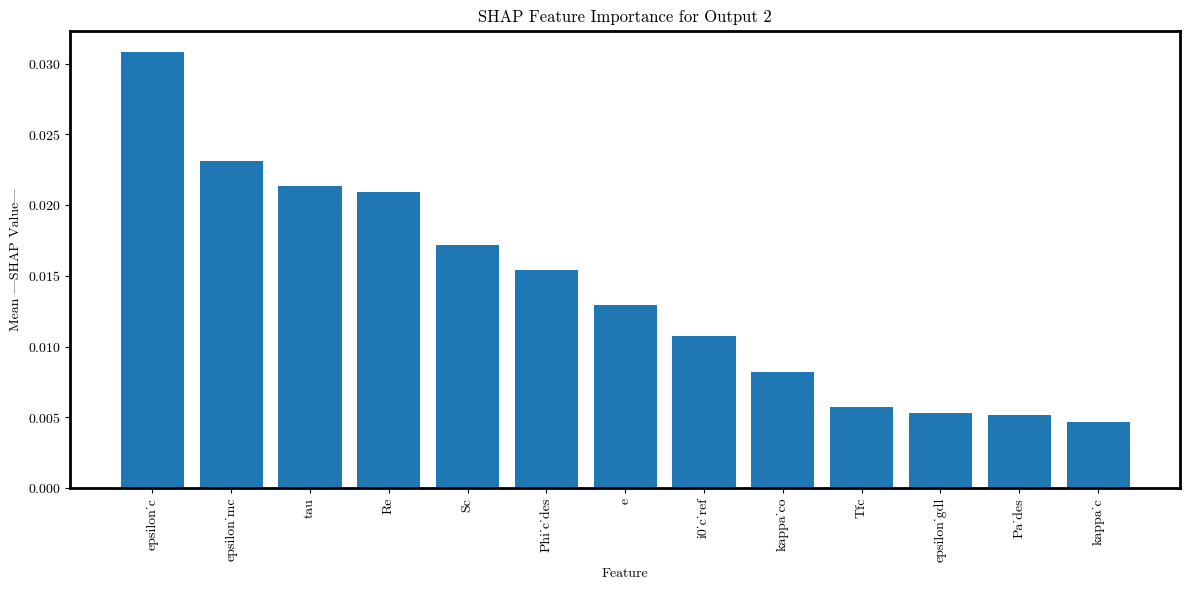

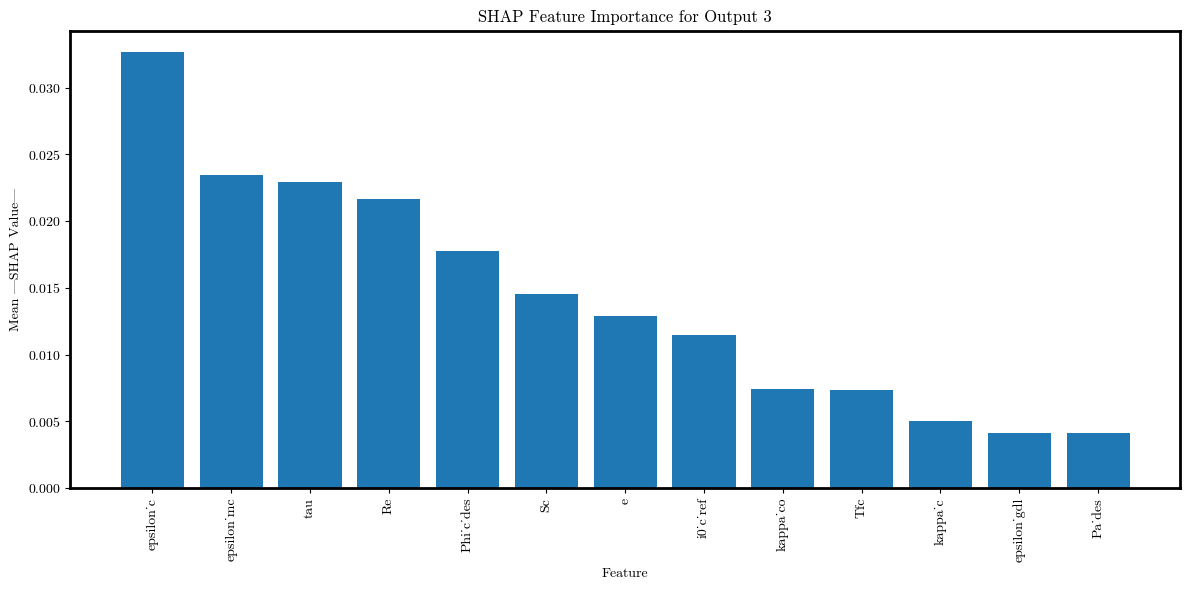

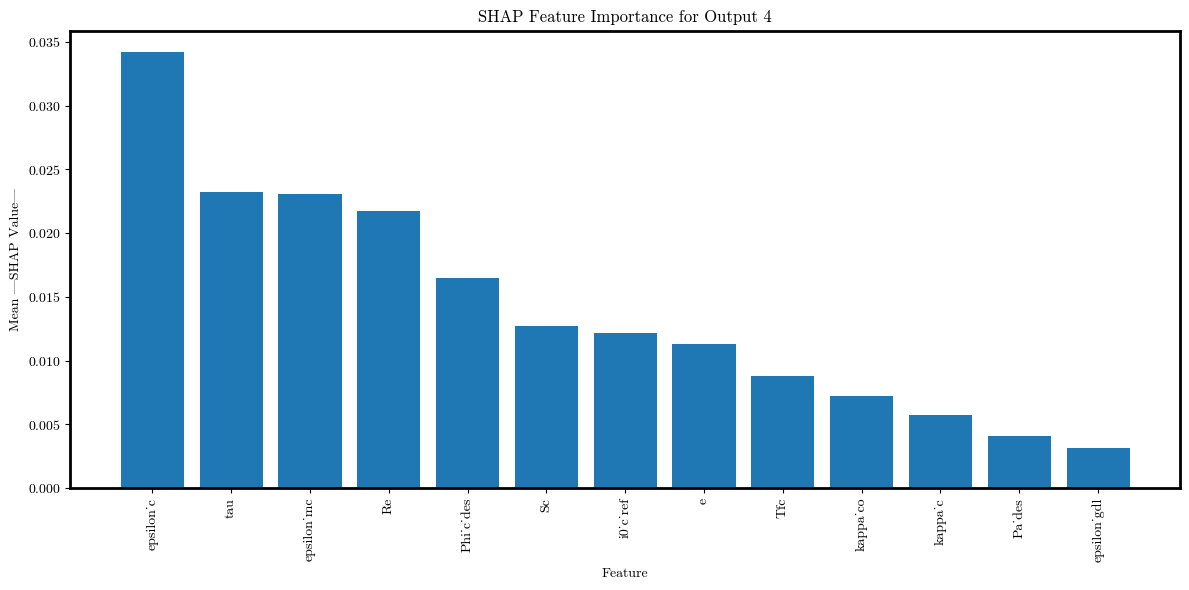

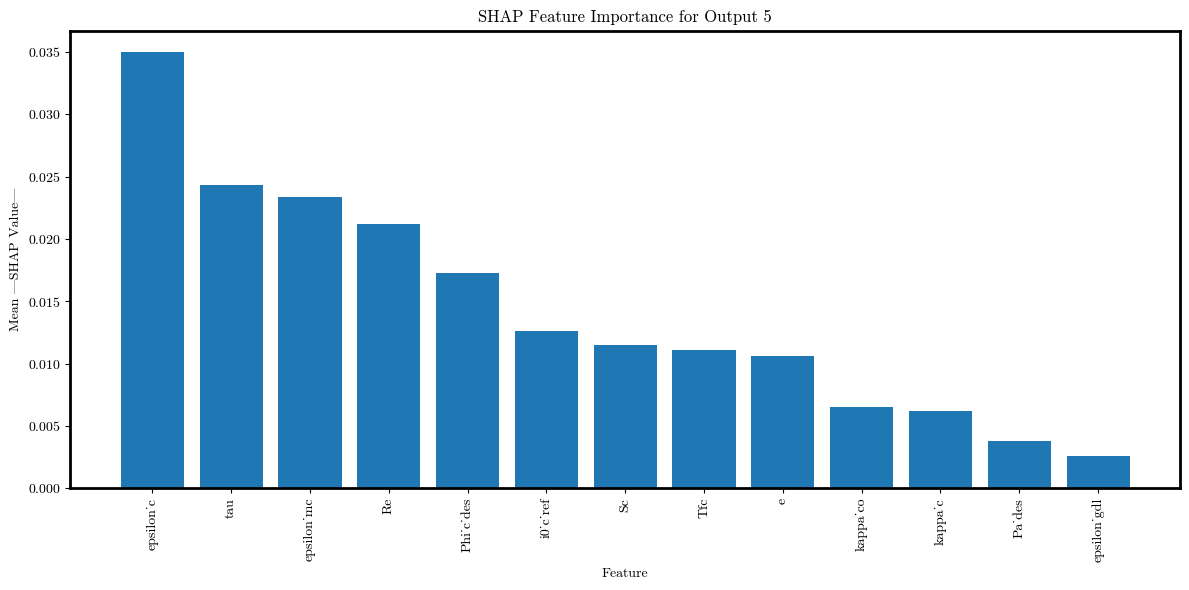

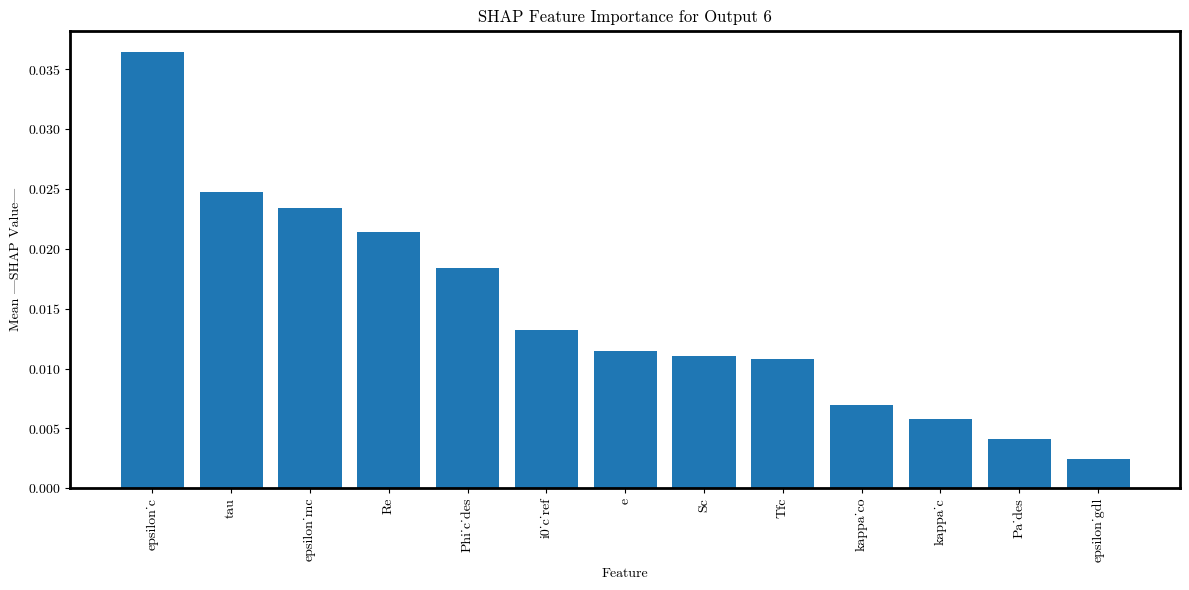

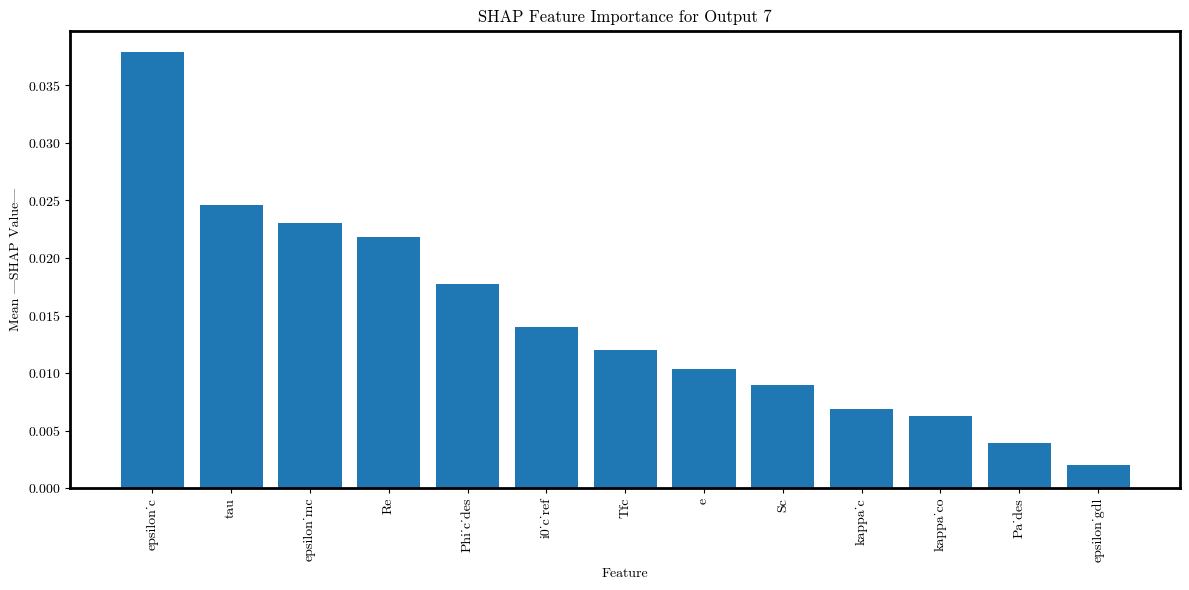

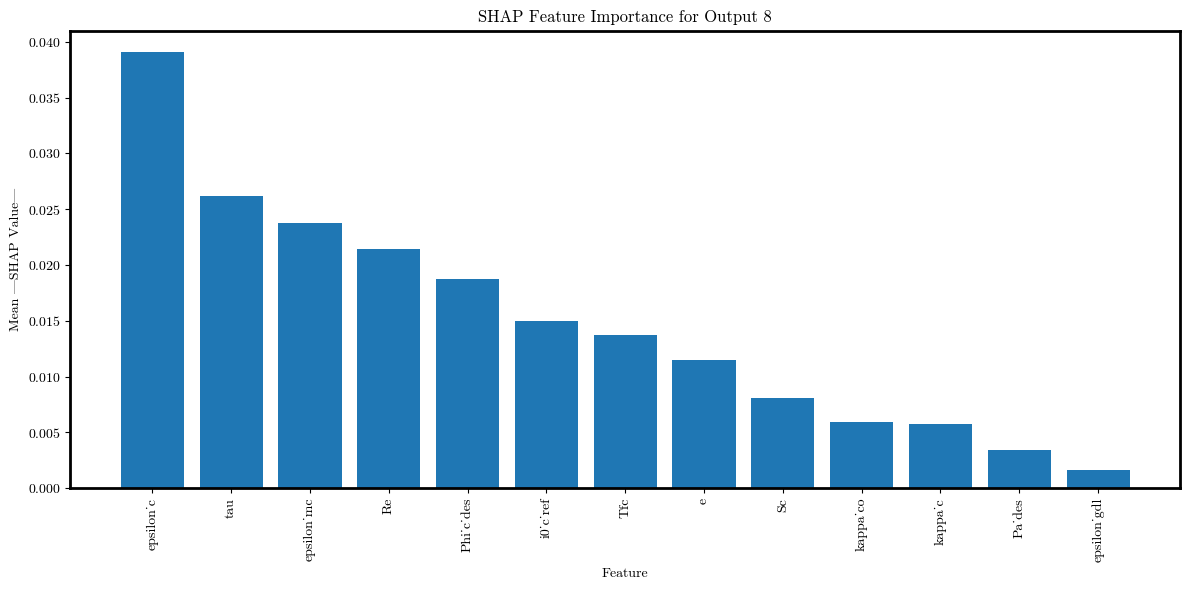

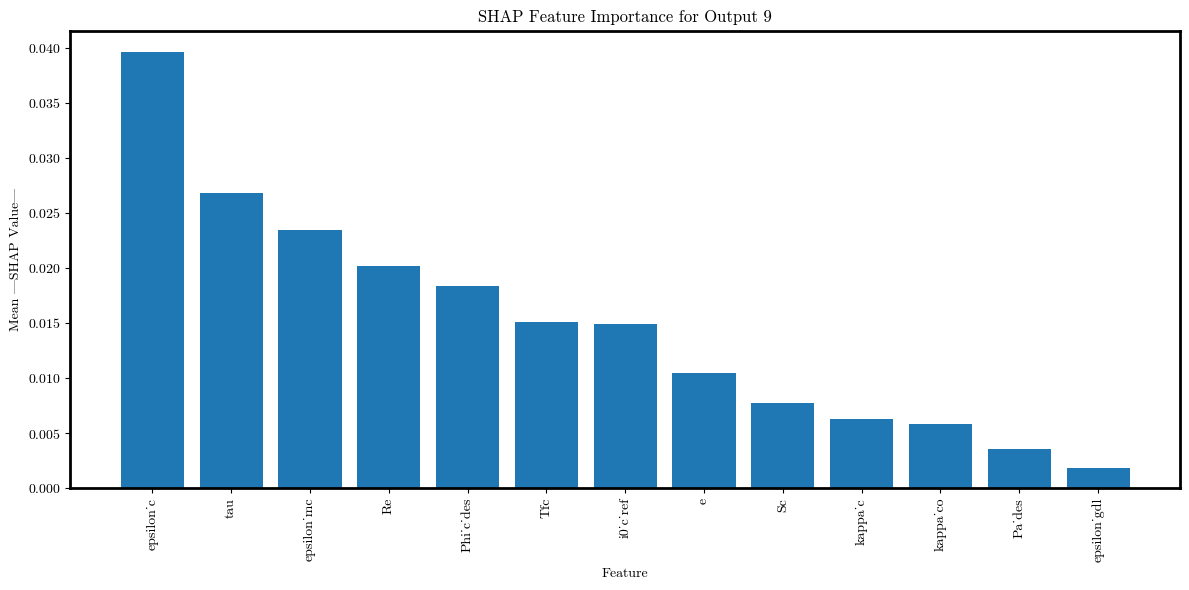

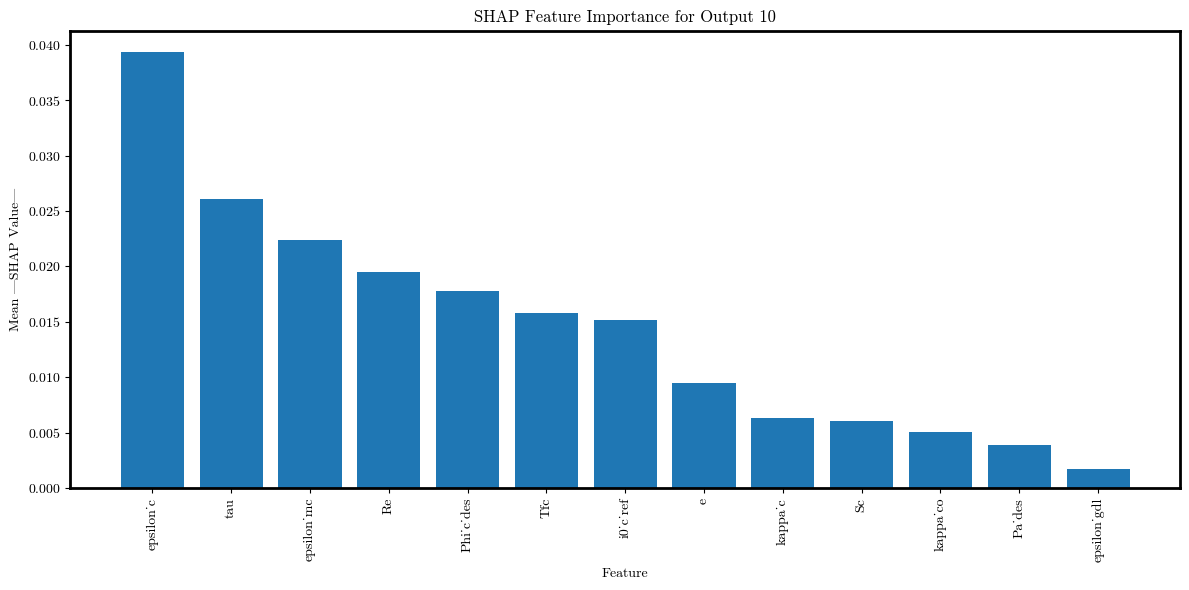

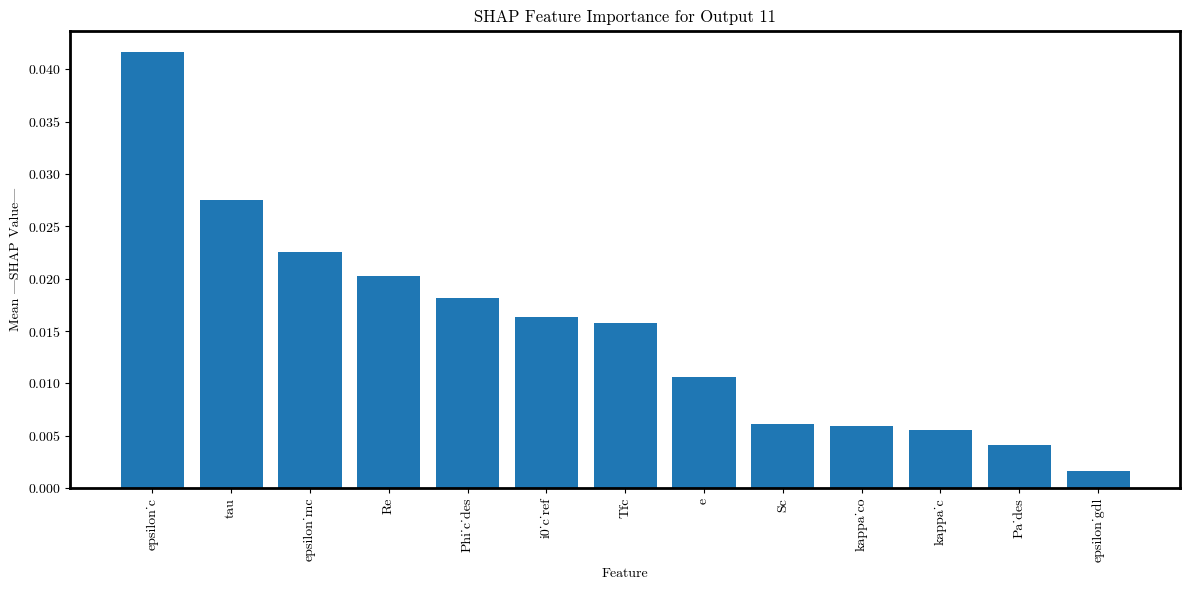

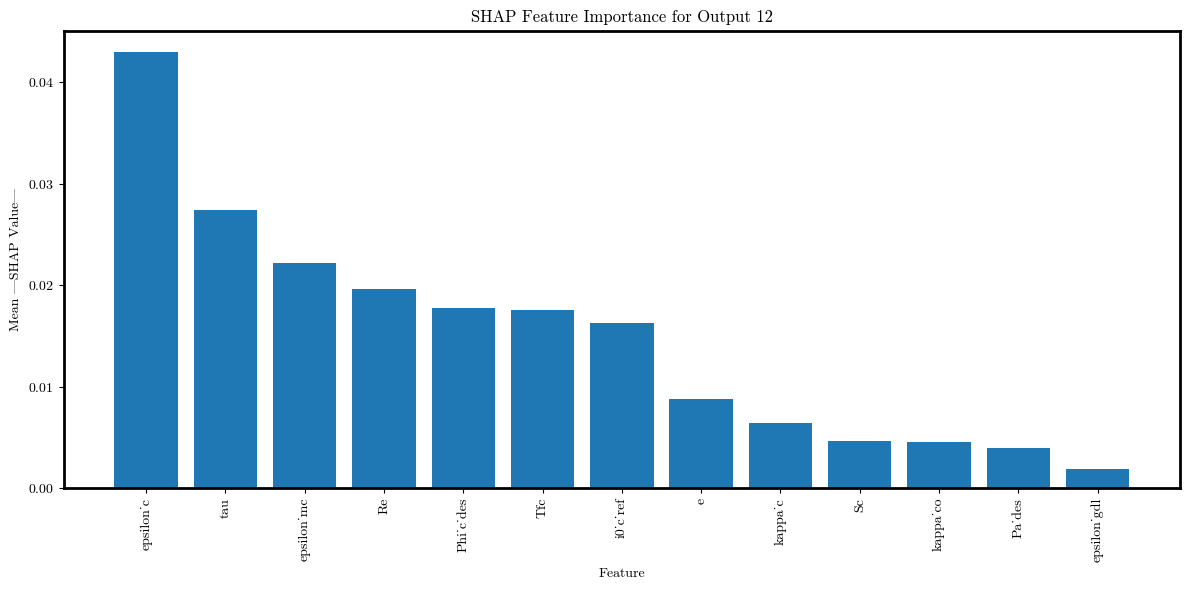

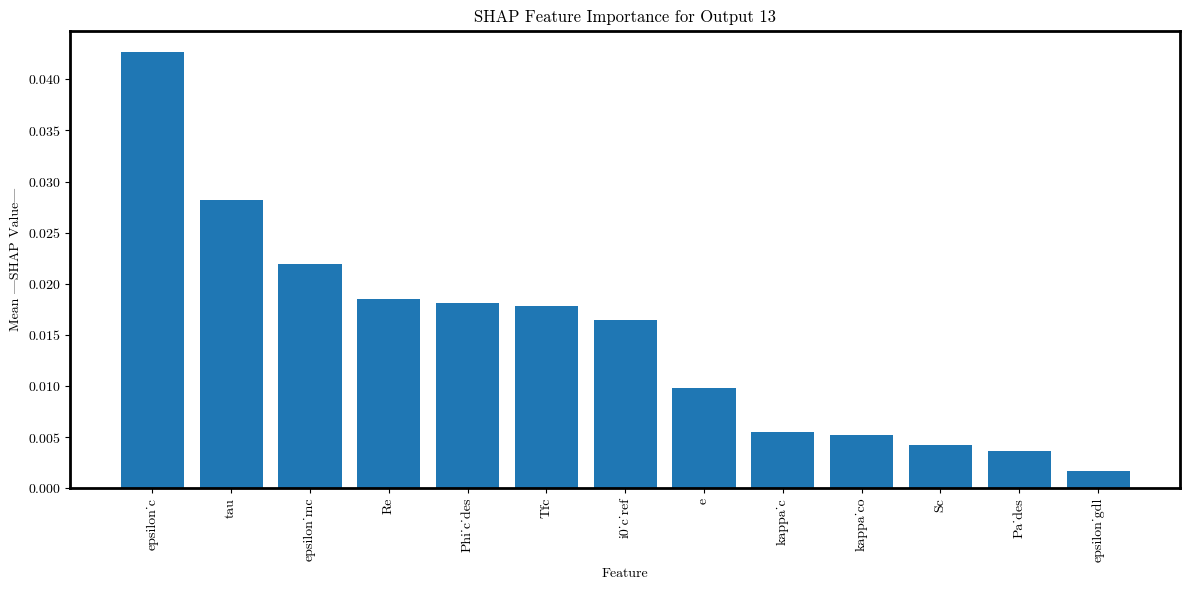

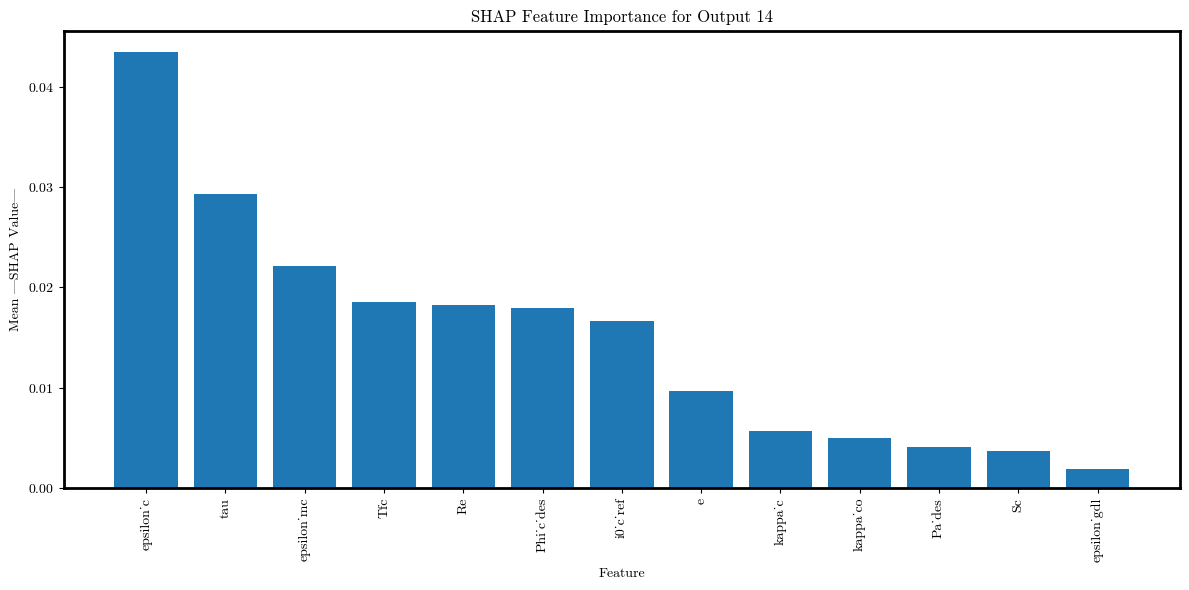

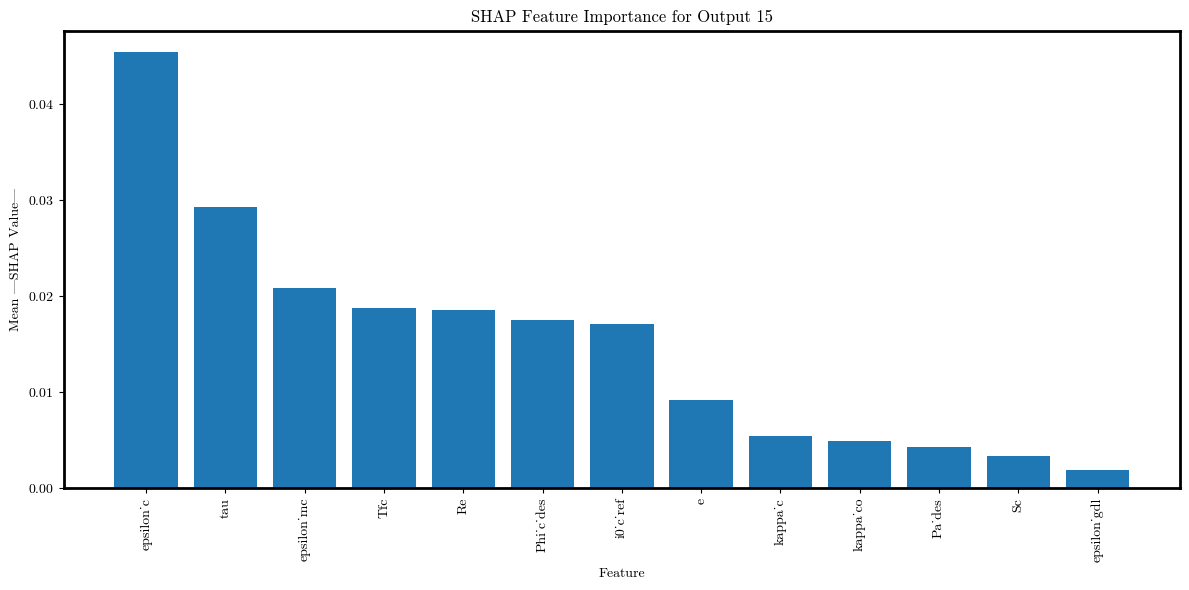

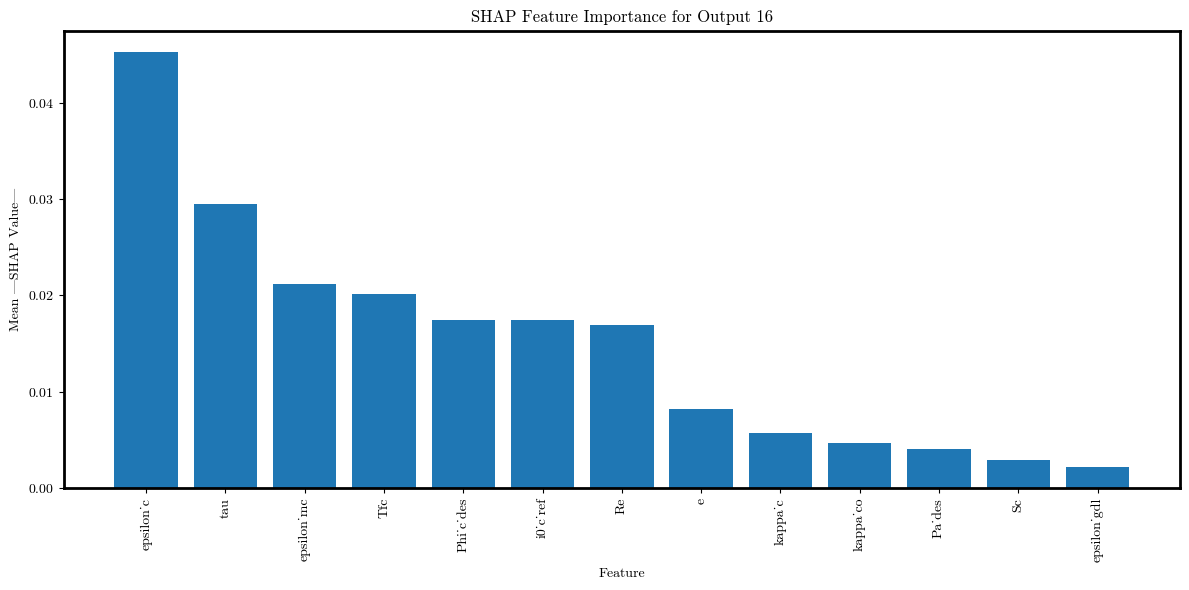

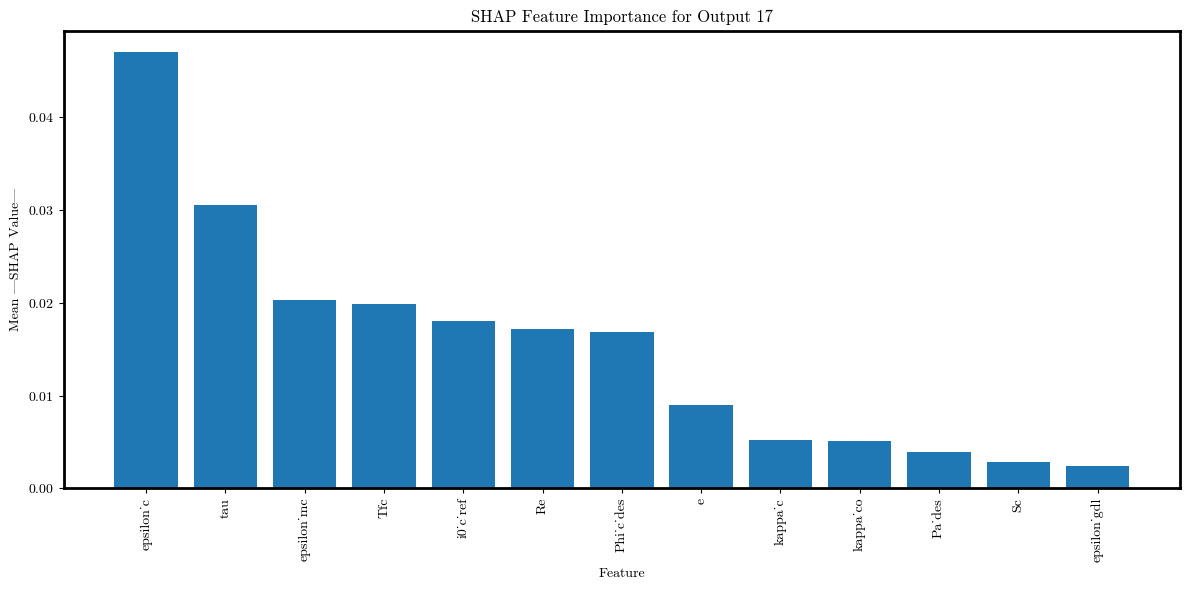

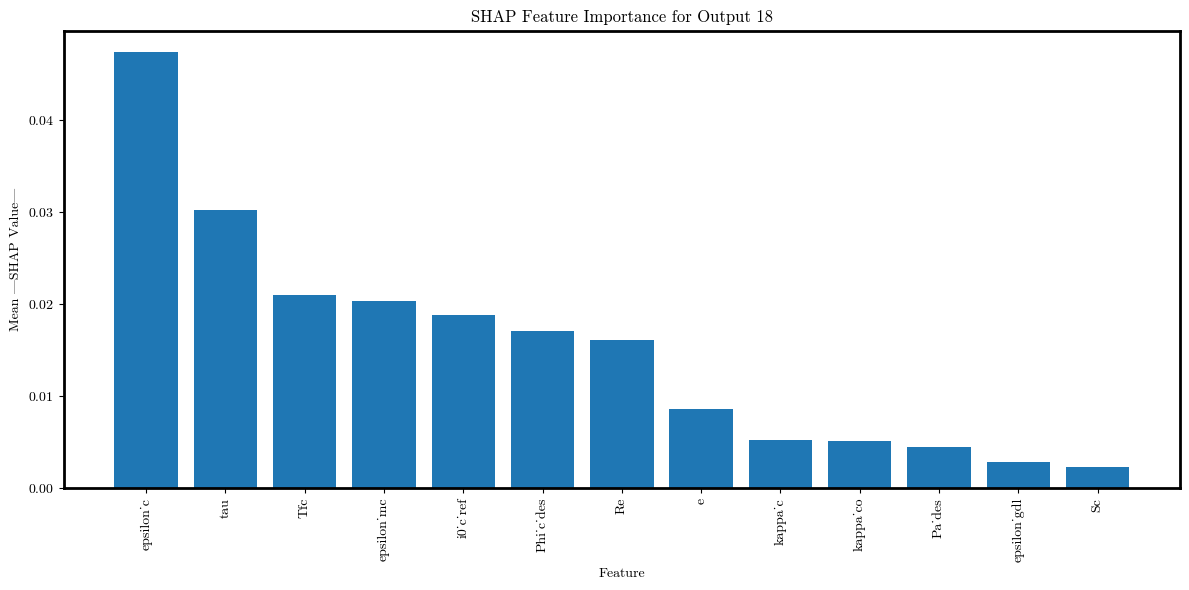

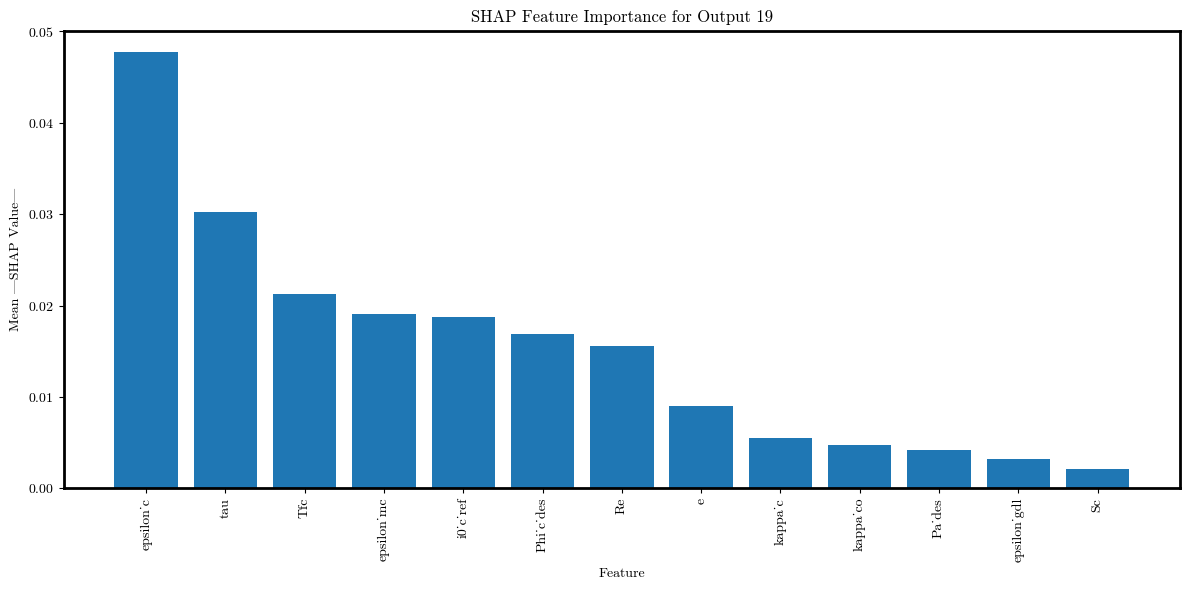

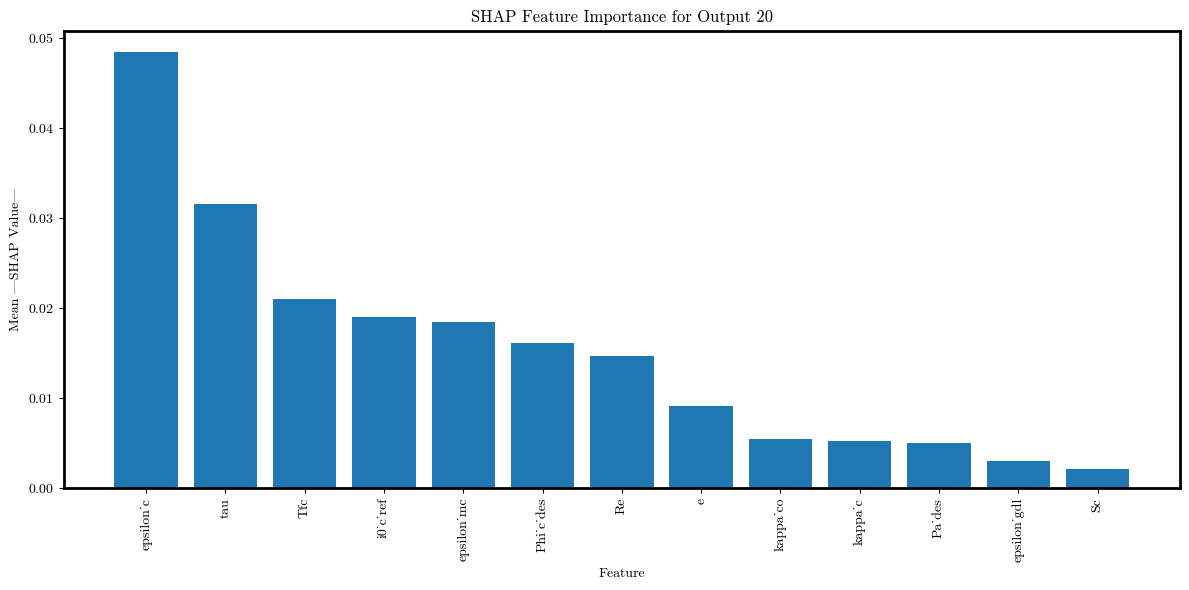

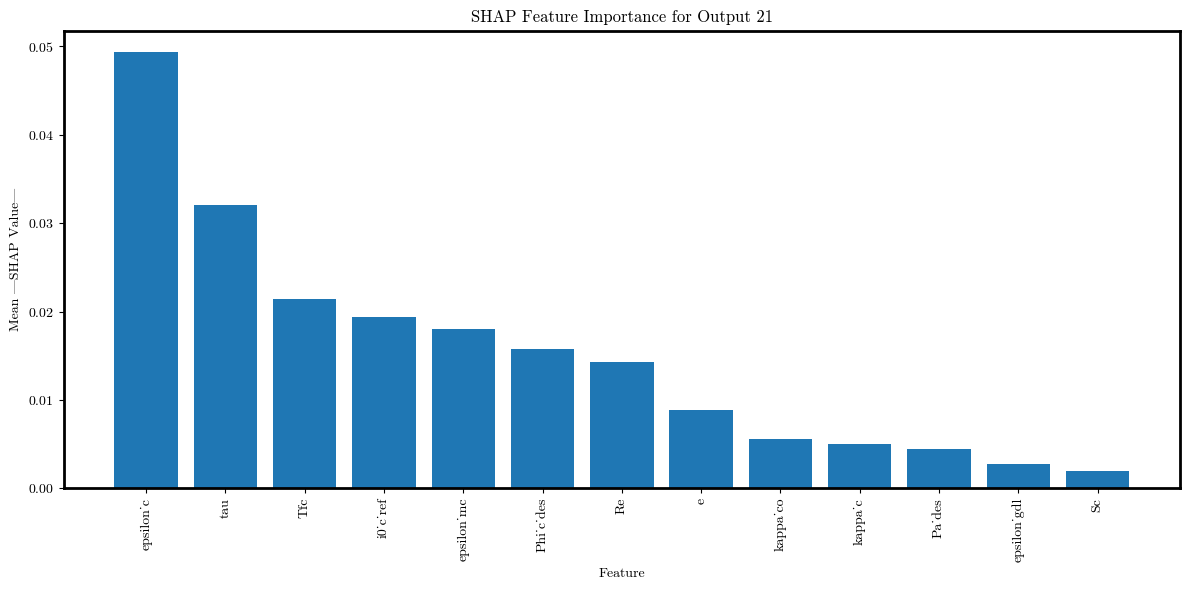

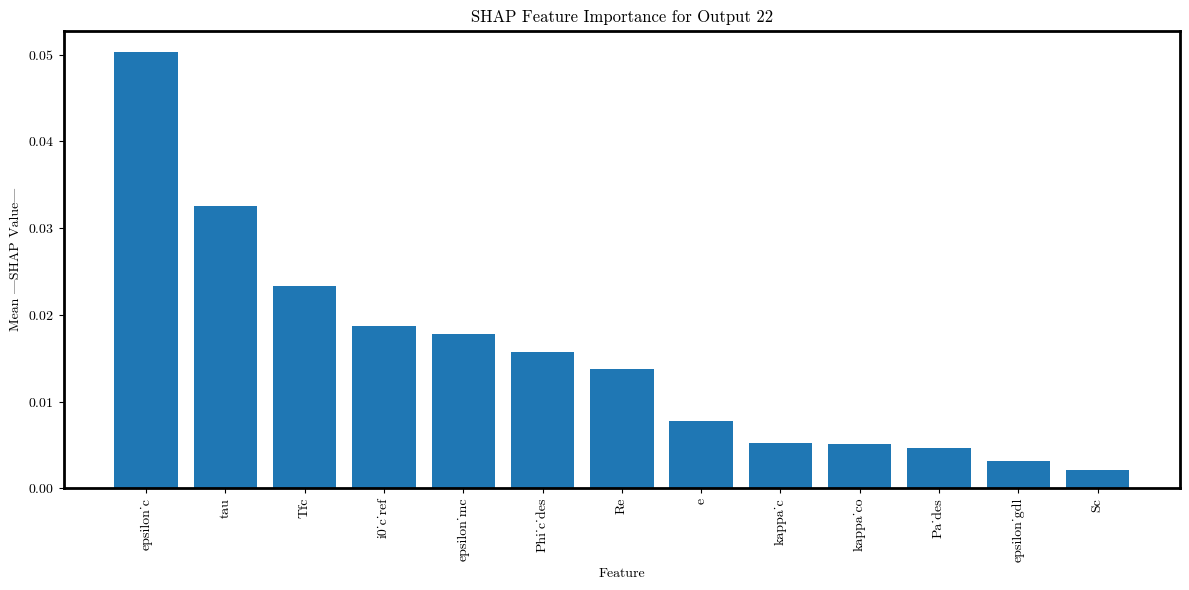

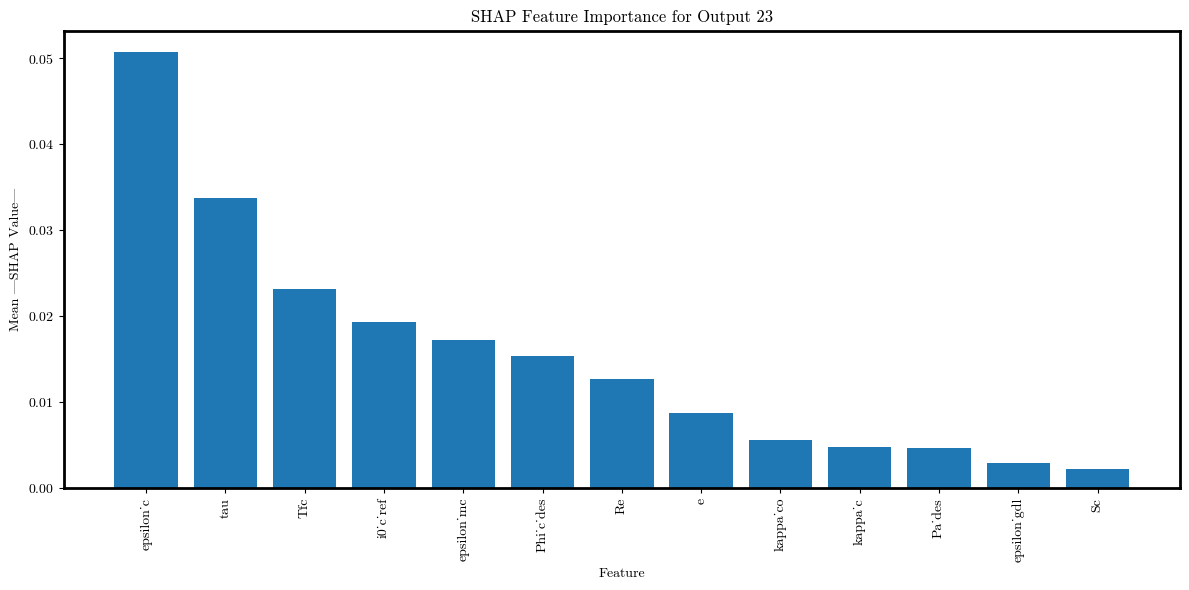

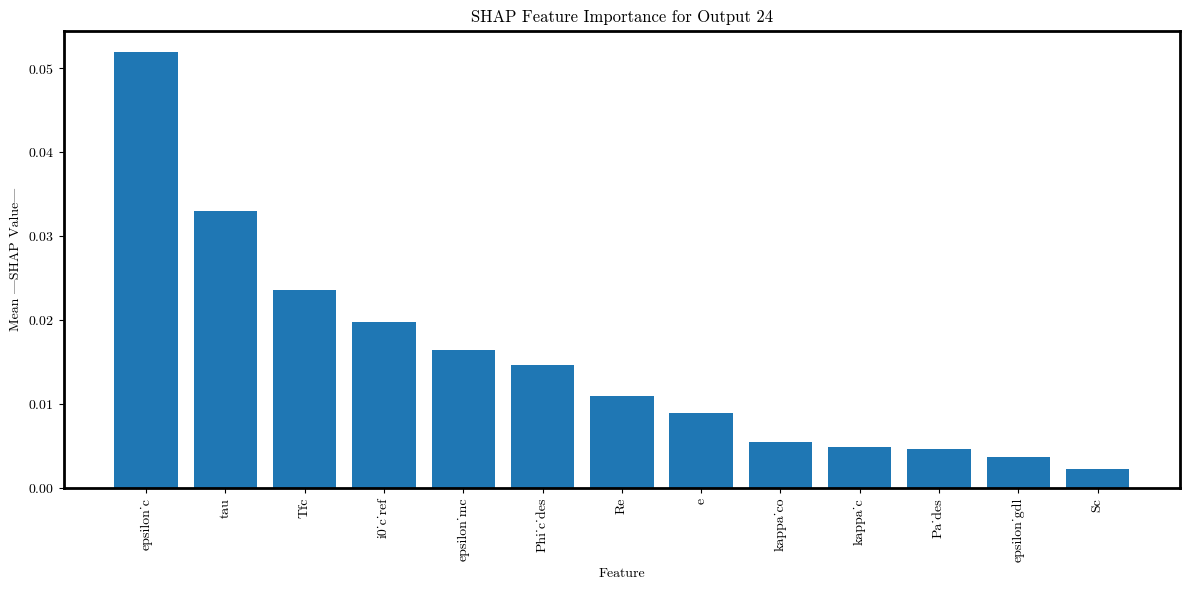

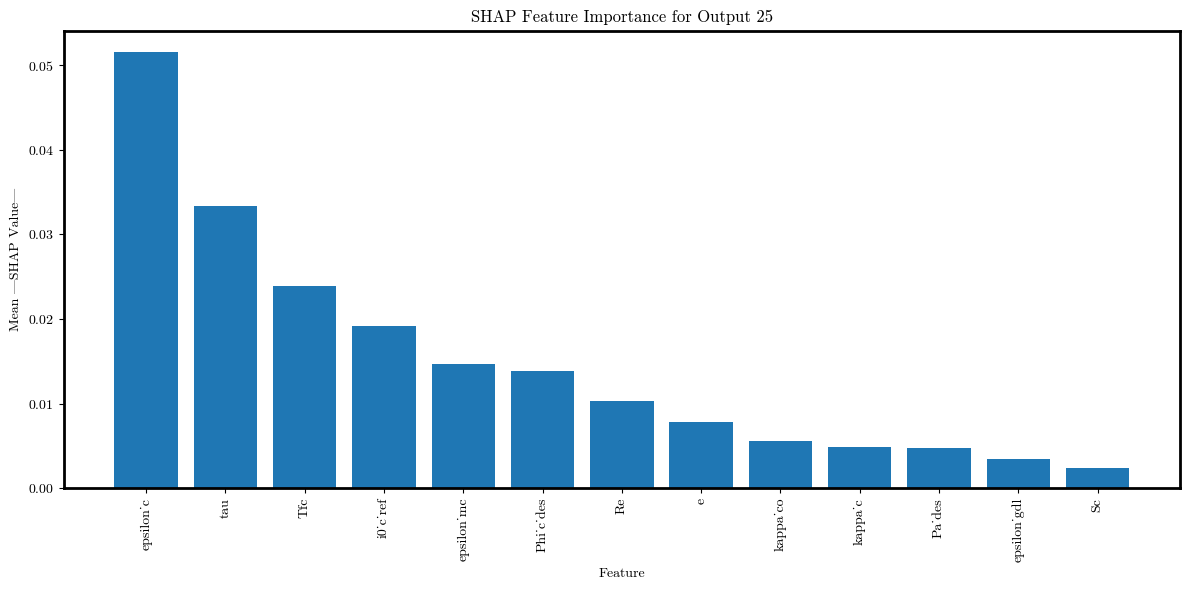

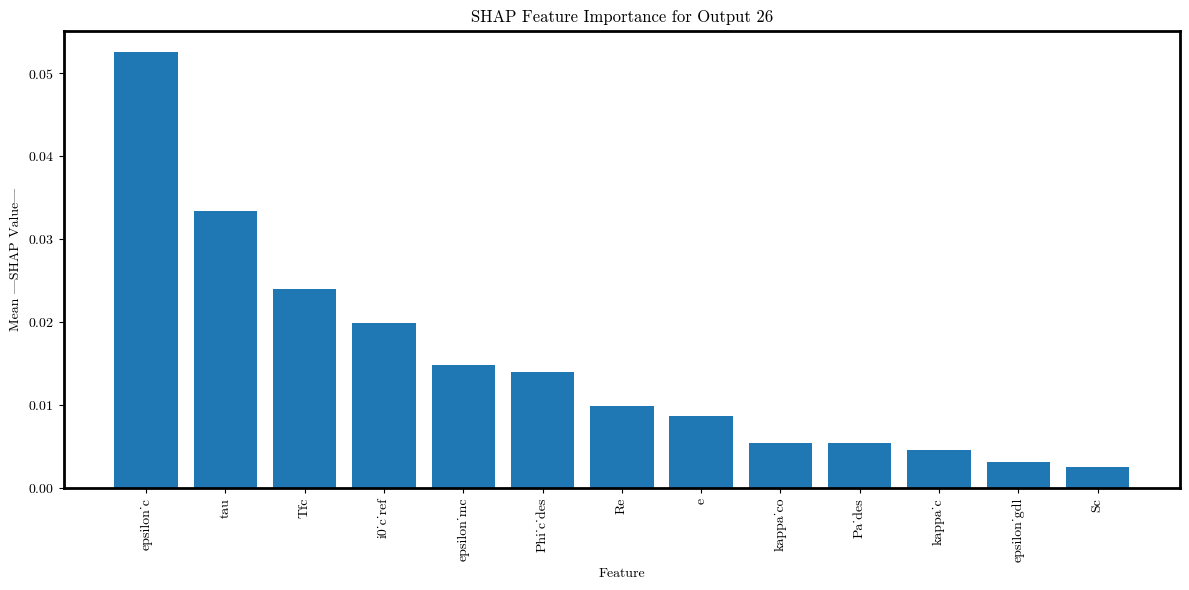

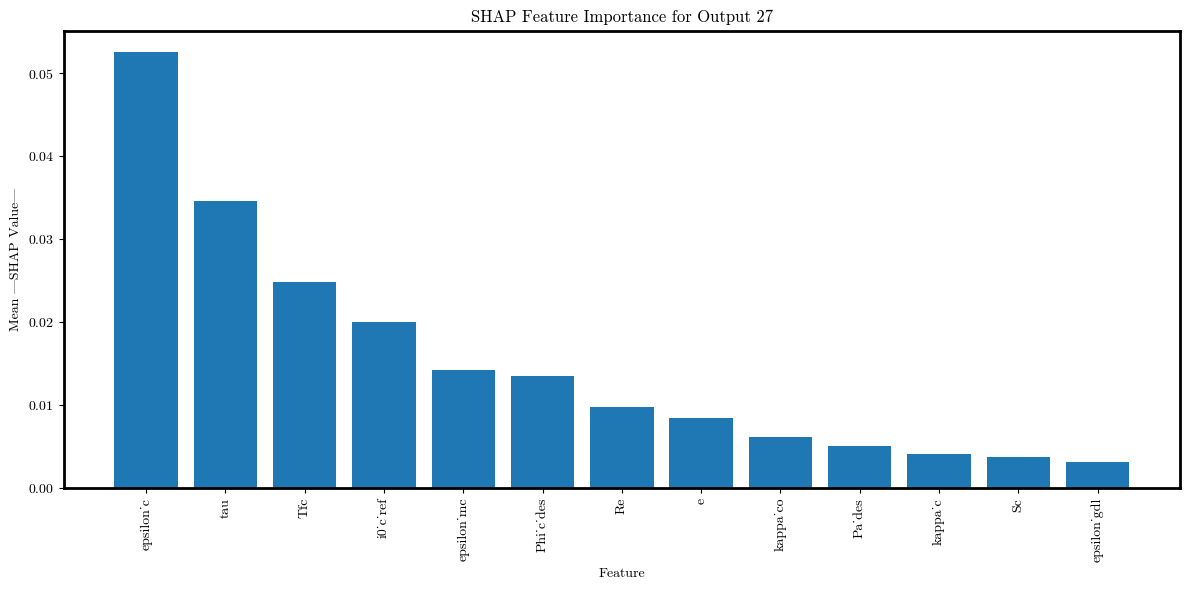

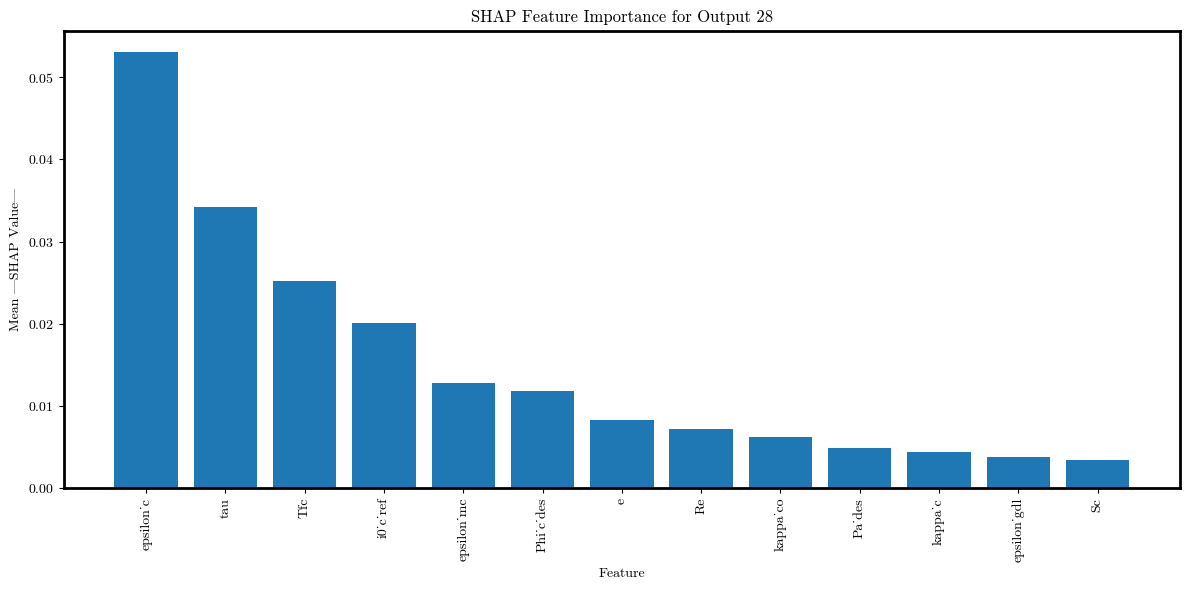

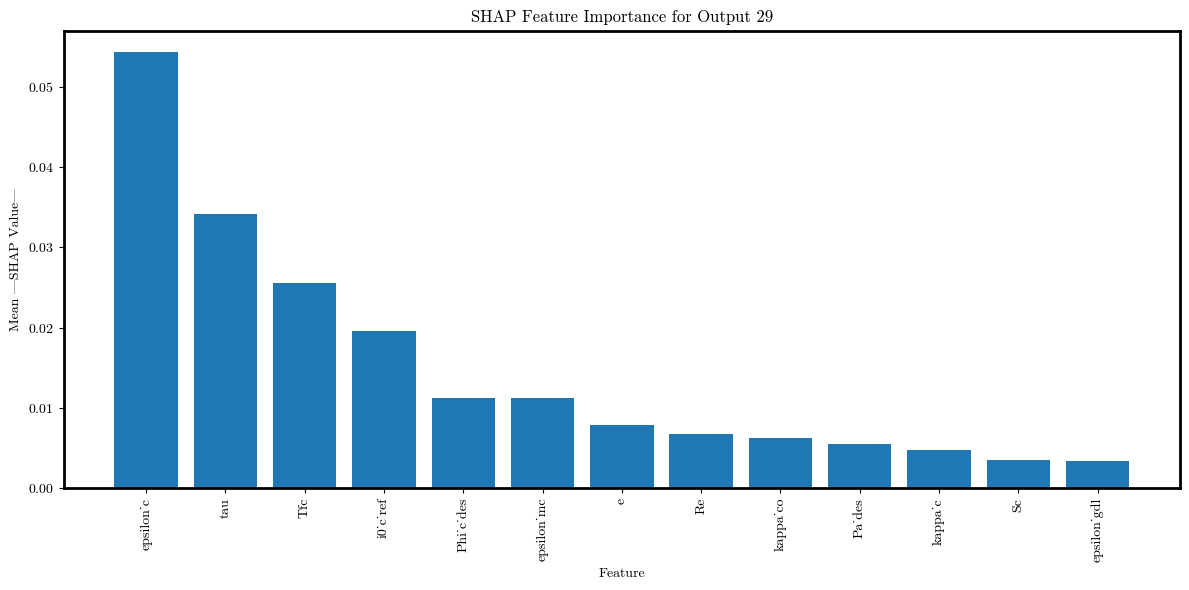

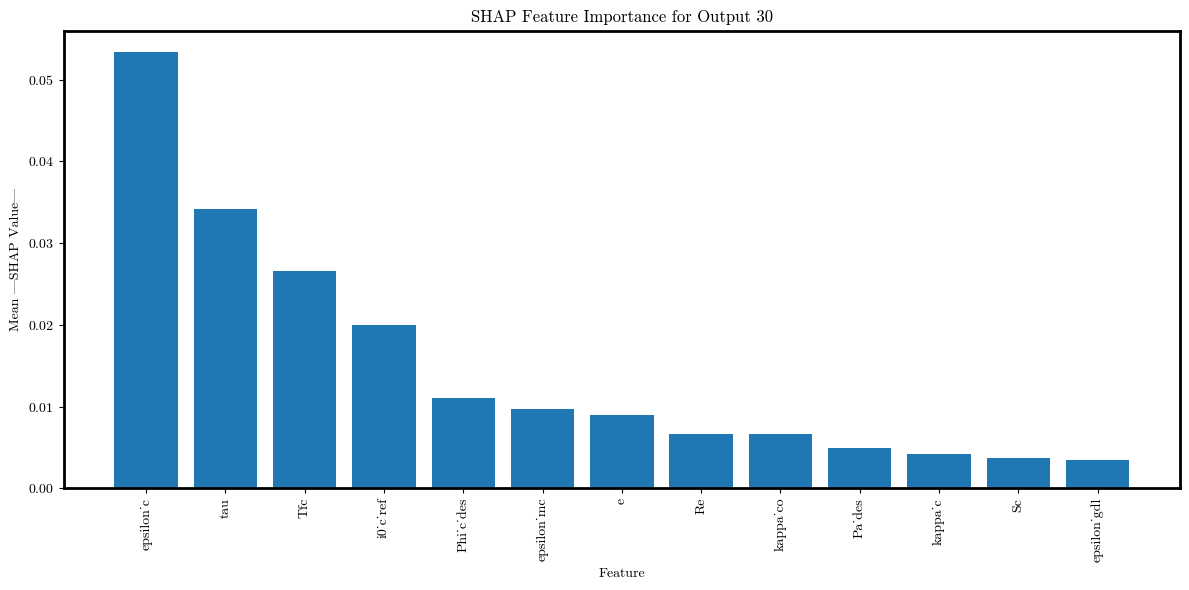

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# Example: list of feature names (make sure it matches your number of features)
# Replace this with your actual feature names list
feature_names = list(parameter_ranges.keys())

for i, shap_values in enumerate(shap_values_list):
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    
    # Sort features by importance descending
    sorted_indices = np.argsort(mean_abs_shap)[::-1]
    sorted_shap = mean_abs_shap[sorted_indices]
    sorted_feature_names = [feature_names[idx] for idx in sorted_indices]

    plt.figure(figsize=(12, 6))
    plt.bar(range(len(sorted_shap)), sorted_shap)
    plt.xticks(ticks=range(len(sorted_shap)), labels=sorted_feature_names, rotation=90)
    plt.xlabel('Feature')
    plt.ylabel('Mean |SHAP Value|')
    plt.title(f'SHAP Feature Importance for Output {i}')
    plt.tight_layout()
    plt.show()


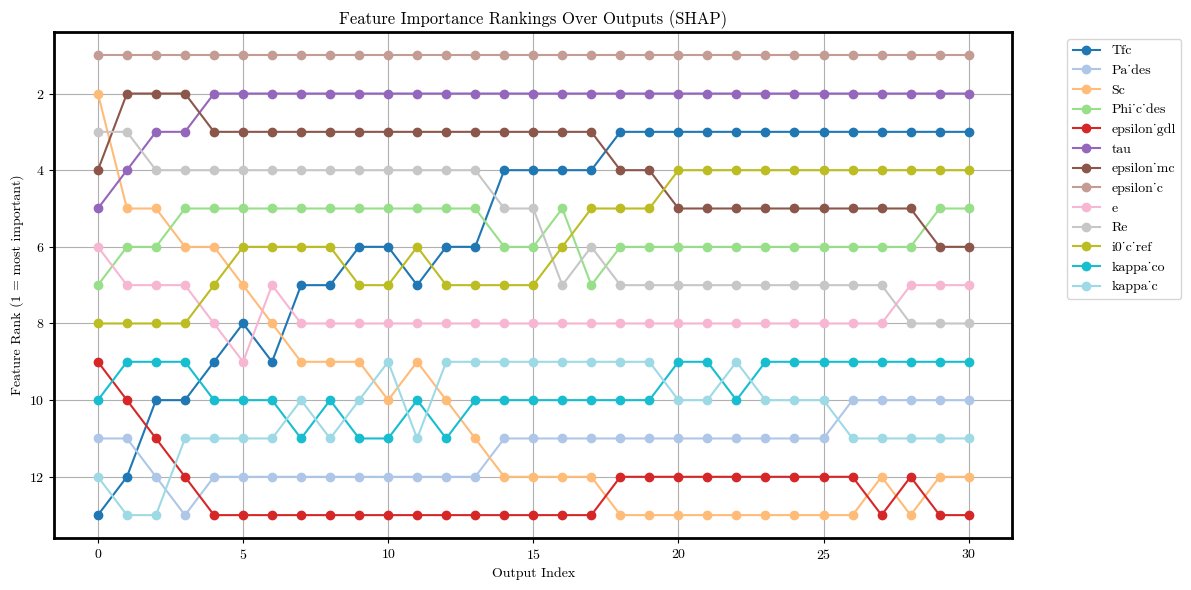

In [46]:
import matplotlib.pyplot as plt
import numpy as np

# Define feature names (adjust as needed)
n_features = shap_values_list[0].shape[1]
feature_names = list(parameter_ranges.keys())
n_outputs = len(shap_values_list)

# Store rankings: shape (n_features, n_outputs)
feature_ranks = np.zeros((n_features, n_outputs), dtype=int)

# Fill the feature_ranks matrix
for output_idx, shap_values in enumerate(shap_values_list):
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    sorted_idx = np.argsort(-mean_abs_shap)  # descending importance
    ranks = np.empty_like(sorted_idx)
    ranks[sorted_idx] = np.arange(1, n_features + 1)
    feature_ranks[:, output_idx] = ranks

# Plot
plt.figure(figsize=(12, 6))
colors = plt.cm.tab20(np.linspace(0, 1, n_features))

for i in range(n_features):
    plt.plot(range(n_outputs), feature_ranks[i], label=feature_names[i], color=colors[i], marker='o')

plt.xlabel('Output Index')
plt.ylabel('Feature Rank (1 = most important)')
plt.title('Feature Importance Rankings Over Outputs (SHAP)')
plt.gca().invert_yaxis()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()
